In [18]:
import zipfile, os
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from collections import Counter
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
import random
from transformers import PreTrainedTokenizerFast
from transformers import GPT2LMHeadModel

# Задание 1

In [3]:
zip_path = "texts.zip"  
extract_dir = "pushkin_poems"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

test_texts = []
for file_name in os.listdir(extract_dir):
    if file_name.endswith(".txt"):
        with open(os.path.join(extract_dir, file_name), "r", encoding="utf-8") as f:
            test_texts.append(f.read())

train_files = ["Алые паруса_1845.txt"] 
train_texts = []
for f in train_files:
    with open(f, "r", encoding="utf-8") as file:
        train_texts.append(file.read())


In [4]:
special_tokens = ["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"]
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(special_tokens=special_tokens, vocab_size=10000)
tokenizer.train(train_files, trainer)  
tokenizer.save("my_bpe_tokenizer.json")

In [5]:
tokenizer = Tokenizer.from_file("my_bpe_tokenizer.json")
tokenized_texts = [tokenizer.encode(t) for t in test_texts]

In [6]:
total_chars = sum(len(t) for t in test_texts)
total_tokens = sum(len(t.ids) for t in tokenized_texts)
compression_ratio = total_tokens / total_chars
print("Compression ratio:", compression_ratio)

Compression ratio: 0.35265169719176503


In [7]:
avg_tokens_per_word = sum(len(t.ids) / len(t.tokens) for t in tokenized_texts) / len(tokenized_texts)
print("Average tokens per word:", avg_tokens_per_word)

Average tokens per word: 1.0


In [8]:
flat_tokens = [token for t in tokenized_texts for token in t.ids]
token_freq = Counter(flat_tokens)
top_10_percent_count = int(len(token_freq) * 0.1)
top_tokens = [t for t, _ in token_freq.most_common(top_10_percent_count)]

avg_tokens_top10 = sum(len(t.ids) / len(t.tokens) for t in tokenized_texts if any(x in top_tokens for x in t.ids)) / len(tokenized_texts)
print("Average tokens per word (top 10% freq tokens):", avg_tokens_top10)

Average tokens per word (top 10% freq tokens): 1.0


In [9]:
vocab = tokenizer.get_vocab()
used_tokens = set(flat_tokens)
unused_tokens = set(vocab.values()) - used_tokens
print(f"Number of unused tokens: {len(unused_tokens)}")

Number of unused tokens: 3966


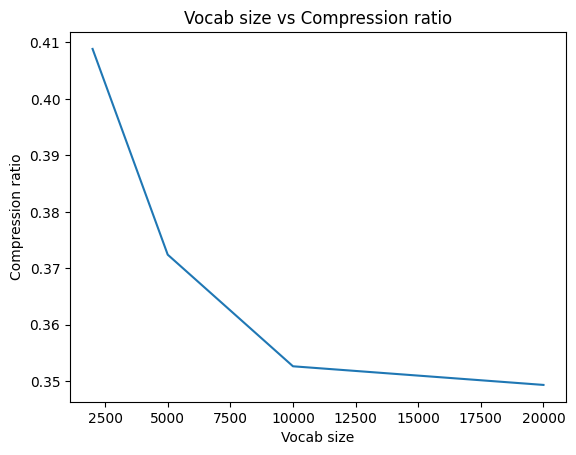

In [10]:
vocab_sizes = [2000, 5000, 10000, 20000]
compression_ratios = []

for vs in vocab_sizes:
    tknzr = Tokenizer(BPE(unk_token="[UNK]"))
    tknzr.pre_tokenizer = Whitespace()
    trainer_vs = BpeTrainer(special_tokens=special_tokens, vocab_size=vs)
    tknzr.train(train_files, trainer_vs)
    
    tokenized = [tknzr.encode(t) for t in test_texts]
    total_tokens_vs = sum(len(t.ids) for t in tokenized)
    compression_ratios.append(total_tokens_vs / total_chars)

plt.plot(vocab_sizes, compression_ratios)
plt.xlabel("Vocab size")
plt.ylabel("Compression ratio")
plt.title("Vocab size vs Compression ratio")
plt.show()

Эффективность токенизации с использованием BPE зависит от домена текста. Токенизатор, обученный на одном корпусе (например, прозе или новостях), показывает лучшую компрессию и меньшее среднее количество токенов на слово для текстов того же домена. Для текстов другого домена (например, стихов Пушкина) эффективность ниже: встречаются редкие слова, архаизмы и нестандартные формы, которые разбиваются на большее количество токенов. Это приводит к увеличению коэффициента сжатия (tokens/символы) и среднего числа токенов на слово. Таким образом, эффективность токенизации существенно отличается между доменами: токенизатор лучше работает на текстах, похожих на обучающий корпус.

# Задание 1.1

In [ ]:
tokenizer = Tokenizer.from_file("my_bpe_tokenizer.json")

all_ids = []
for t in test_texts:
    enc = tokenizer.encode(t)
    all_ids.extend(enc.ids)


In [ ]:
SEQ_LEN = 32
BATCH_SIZE = 64

In [ ]:
class TokenDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len

    def __len__(self):
        return len(self.ids) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx:idx+self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx+1:idx+self.seq_len+1], dtype=torch.long)
        return x, y

In [ ]:
dataset = TokenDataset(all_ids, SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [12]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.fc(out)
        return out

vocab_size = tokenizer.get_vocab_size()
model = SimpleRNN(vocab_size)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


SimpleRNN(
  (embedding): Embedding(10000, 128)
  (rnn): RNN(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=10000, bias=True)
)

In [15]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 1

for epoch in range(EPOCHS):
    total_loss = 0
    # tqdm по батчам в каждой эпохе
    for x, y in tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        # CrossEntropyLoss ожидает (batch*seq_len, vocab_size) и (batch*seq_len)
        loss = criterion(outputs.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(dataloader):.4f}")


Epoch 1/1: 100%|██████████| 3967/3967 [35:43<00:00,  1.85it/s]    

Epoch 1/1, Loss: 3.3704


In [16]:
def generate_text(model, tokenizer, start_text, length=50):
    model.eval()
    ids = tokenizer.encode(start_text).ids
    input_ids = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
    generated = ids.copy()

    with torch.no_grad():
        for _ in range(length):
            output = model(input_ids)
            next_token_logits = output[0, -1, :]
            next_token_id = torch.argmax(next_token_logits).item()
            generated.append(next_token_id)
            input_ids = torch.tensor(generated[-SEQ_LEN:], dtype=torch.long).unsqueeze(0).to(device)

    decoded = tokenizer.decode(generated)
    return decoded

sample_text = generate_text(model, tokenizer, start_text="Мороз и солнце")
print(sample_text)


Мо роз и солнце , И насла ж день я ! Но ты , как мол ва в сегодня ме й , О друзь я мои , Мой друг , не вер ный круг ! И с чез ли з ла тые ночи , И ль пола чи тся в круг х лад ны


# Задание 1.2

In [19]:
tokenizer = PreTrainedTokenizerFast(
    tokenizer_file="my_bpe_tokenizer.json",
    unk_token="[UNK]",
    pad_token="[PAD]",
    bos_token="[CLS]",
    eos_token="[SEP]"
)

In [20]:
model = GPT2LMHeadModel.from_pretrained("gpt2")

model.resize_token_embeddings(len(tokenizer))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

c:\Users\kamil\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kamil\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Embedding(10000, 768)

In [21]:
class GPTDataset(Dataset):
    def __init__(self, texts, tokenizer, block_size=128):
        self.examples = []
        for text in texts:
            ids = tokenizer.encode(text)
            for i in range(0, len(ids) - block_size, block_size):
                self.examples.append(
                    torch.tensor(ids[i:i+block_size], dtype=torch.long)
                )

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, i):
        return self.examples[i]

dataset = GPTDataset(test_texts, tokenizer)

In [22]:
dataloader = DataLoader(
    dataset,
    batch_size=2,      
    shuffle=True
)

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
EPOCHS = 1

model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        batch = batch.to(device)
        optimizer.zero_grad()

        outputs = model(input_ids=batch, labels=batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(dataloader):.4f}")

Epoch 1/1: 100%|██████████| 778/778 [30:02<00:00,  2.32s/it] 

Epoch 1, Loss: 6.2100


In [24]:
prompt = "Мороз и солнце"
input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    output = model.generate(
        input_ids,
        max_length=50,
        do_sample=True,
        top_k=50
    )

print(tokenizer.decode(output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Мо роз и солнце , ты в т б ю , и ны в , не день , как ла с я ны , не , ли он ю С ю го ; И и ж ю ли . И и ной в у то д , т ни ко
